## Notebook Description: Análisis Estadístico de Aditivos Bios y Metano

Este notebook tiene como objetivo principal realizar un análisis estadístico de los efectos de diferentes `Treatment` (tratamientos) en variables como el porcentaje de materia seca digerible total ($\text{TDDM_percentage}$) y la intensidad de metano ($\text{CH4_ml_g_DMD_24h}$) en un estudio con aditivos biológicos. La metodología incluye la carga y exploración inicial de los datos, la visualización de la distribución de las variables mediante boxplots, y un análisis de varianza. Dado que las pruebas preliminares (Shapiro-Wilk para normalidad y Bartlett para homocedasticidad) indicaron que los datos para $\text{TDDM_percentage}$ no cumplen con los supuestos paramétricos requeridos para un ANOVA ($p < 0.05$), se optó por aplicar pruebas no paramétricas. Para ambas variables clave, $\text{TDDM_percentage}$ y $\text{CH4_ml_g_DMD_24h}$, se realizó un test de Kruskal-Wallis, que reveló diferencias entre los grupos de tratamiento ($p < 0.05$). Posteriormente, se aplicaron pruebas post-hoc de Dunn con ajuste de Holm para identificar los tratamientos específicos que difieren. Los resultados de estas pruebas post-hoc se integraron visualmente en los boxplots mediante letras que denotan los grupos estadísticamente similares.

# 1.0 Install packages and import libraries

In [88]:
install.packages(c("dplyr", "ggplot2", "rstatix", "multcompView"))

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [117]:
library(ggplot2)
library(dplyr)
library(rstatix)
library(multcompView)

# 2.0 Data load

In [90]:
url_df <- "https://raw.githubusercontent.com/maurope/lmf/main/data/2026_09_11_R_bios_diets_anaylisis_for_alejandra/Additives_Bios_AM.csv"
df <- read.csv(url_df)

In [91]:
head(df)

,X.,Treatment,Additive,Batch,Run,Replication,Syrange_No,Sample_weight_g,DM_Incubated_mg,Digested_feed_mg,⋯,CH4_percentage_in_gas_8h,CH4_percentage_in_gas_24h,CH4_ml_g_DM_incubated_24h,CH4_ml_g_DMD_24h,CH4_g_g_DM_incubated_24h,CH4_g_g_DMD_24h,pH,NH4_ppm,BLANK_24H_promedio_corrida_ppm,Amonio_corregido_ppm
,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,T0,CTRL_PREM,95,1,1,3,0.5006,447.1,359.9,⋯,14.8,15.0,42.3,52.6,23.5,29.2,7.39,360.7,419.25,-58.55
2,2,T0,CTRL_PREM,95,1,2,4,0.5001,446.6,370.8,⋯,15.9,15.6,46.2,55.7,25.7,30.9,7.29,455.1,419.25,35.85
3,3,T0,CTRL_PREM,95,1,3,5,0.5002,446.7,351.8,⋯,16.0,15.9,42.3,53.7,23.5,29.8,7.21,404.6,419.25,-14.65
4,4,T0,CTRL_PREM,96,2,1,3,0.5003,446.8,330.8,⋯,15.3,15.7,43.5,58.8,24.2,32.6,7.57,357.6,363.40,-5.80
5,5,T0,CTRL_PREM,96,2,2,4,0.5000,446.6,350.9,⋯,16.4,16.0,44.9,57.2,24.9,31.7,7.40,292.2,363.40,-71.20
6,6,T0,CTRL_PREM,96,2,3,5,0.5001,446.6,351.1,⋯,16.4,16.1,44.9,57.1,24.9,31.7,7.43,359.6,363.40,-3.80


In [92]:
df$Treatment <- factor(df$Treatment, levels = paste0("T", sort(as.numeric(sub("T", "", unique(df$Treatment)))))) # Sorting treatments numerically for ordered visualization in box plots

# 3.0 Summary

In [93]:
nrow(df)  # number of rows
ncol(df)  # number of columns

[1] 333

[1] 24

In [94]:
names(df) # Columns names

[1] "X."                             "Treatment"                     
 [3] "Additive"                       "Batch"                         
 [5] "Run"                            "Replication"                   
 [7] "Syrange_No"                     "Sample_weight_g"               
 [9] "DM_Incubated_mg"                "Digested_feed_mg"              
[11] "CH4_24h_ml"                     "Gas_ml_g_DM_Incubated_24h"     
[13] "TDDM_percentage"                "Part_Fact"                     
[15] "CH4_percentage_in_gas_8h"       "CH4_percentage_in_gas_24h"     
[17] "CH4_ml_g_DM_incubated_24h"      "CH4_ml_g_DMD_24h"              
[19] "CH4_g_g_DM_incubated_24h"       "CH4_g_g_DMD_24h"               
[21] "pH"                             "NH4_ppm"                       
[23] "BLANK_24H_promedio_corrida_ppm" "Amonio_corregido_ppm"

In [95]:
glimpse(df)

Rows: 333
Columns: 24
$ X.                             <int> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, …
$ Treatment                      <fct> T0, T0, T0, T0, T0, T0, T0, T0, T0, T1,…
$ Additive                       <chr> "CTRL_PREM", "CTRL_PREM", "CTRL_PREM", …
$ Batch                          <int> 95, 95, 95, 96, 96, 96, 97, 97, 97, 95,…
$ Run                            <int> 1, 1, 1, 2, 2, 2, 3, 3, 3, 1, 1, 1, 2, …
$ Replication                    <int> 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, …
$ Syrange_No                     <int> 3, 4, 5, 3, 4, 5, 3, 4, 5, 6, 7, 8, 6, …
$ Sample_weight_g                <dbl> 0.5006, 0.5001, 0.5002, 0.5003, 0.5000,…
$ DM_Incubated_mg                <dbl> 447.1, 446.6, 446.7, 446.8, 446.6, 446.…
$ Digested_feed_mg               <dbl> 359.9, 370.8, 351.8, 330.8, 350.9, 351.…
$ CH4_24h_ml                     <dbl> 18.9, 20.7, 18.9, 19.5, 20.1, 20.1, 19.…
$ Gas_ml_g_DM_Incubated_24h      <dbl> 282.7, 296.4, 266.2, 277.8, 281.3, 279.…
$ TDDM_percentage 

# 4.0 Data visualization

## 4.1 Boxplot TDDM %

Warning message:
“Removed 5 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_point()`).”


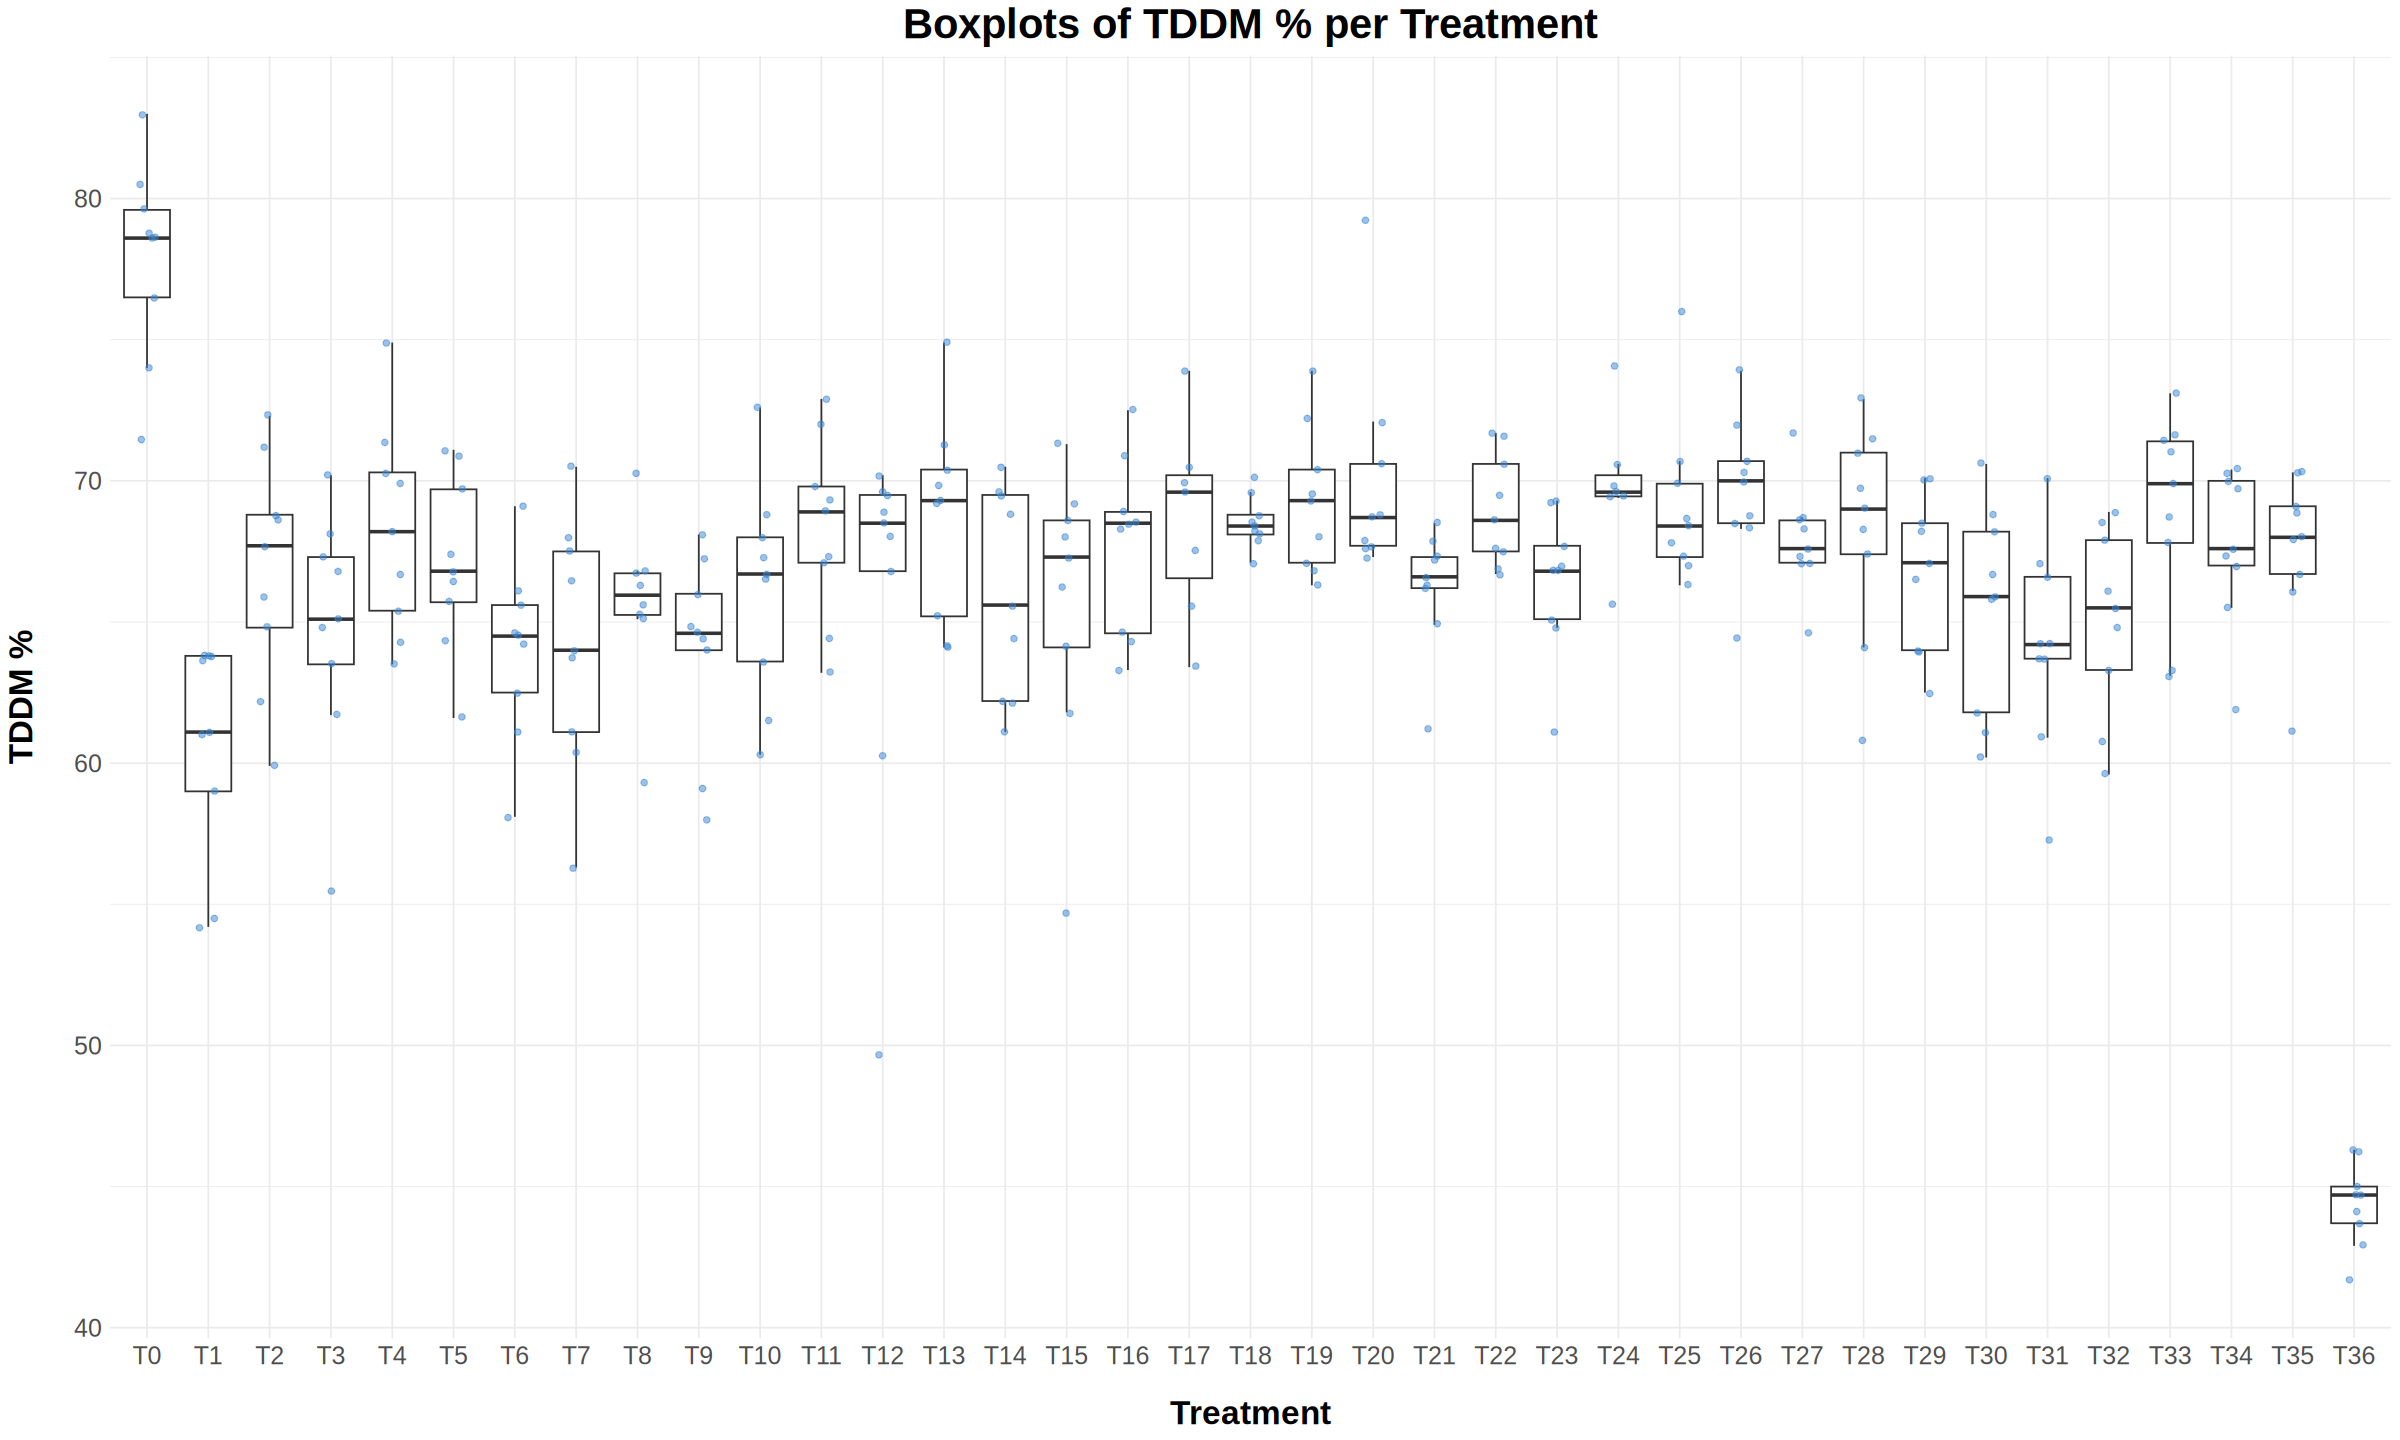

In [96]:
options(repr.plot.width=20, repr.plot.height=12)
ggplot(df, aes(x = Treatment, y = TDDM_percentage)) +
      geom_boxplot(outlier.shape = NA) +
      geom_jitter(width = 0.15, alpha = 0.5, color = "#3a86d4") +
      labs(title = "Boxplots of TDDM % per Treatment", x = "Treatment", y = "TDDM %") +
      theme_minimal() +
      theme(
        plot.title = element_text(size = 25, face = "bold", hjust = 0.5),
        axis.title.x = element_text(size = 20, face = "bold",  margin = margin(t = 20)),
        axis.title.y = element_text(size = 20, face = "bold",  margin = margin(r = 20)),
        axis.text.x = element_text(size = 15),
        axis.text.y = element_text(size = 15)
      )

## 4.2 Boxplot Methane Intensity

Warning message:
“Removed 5 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_point()`).”


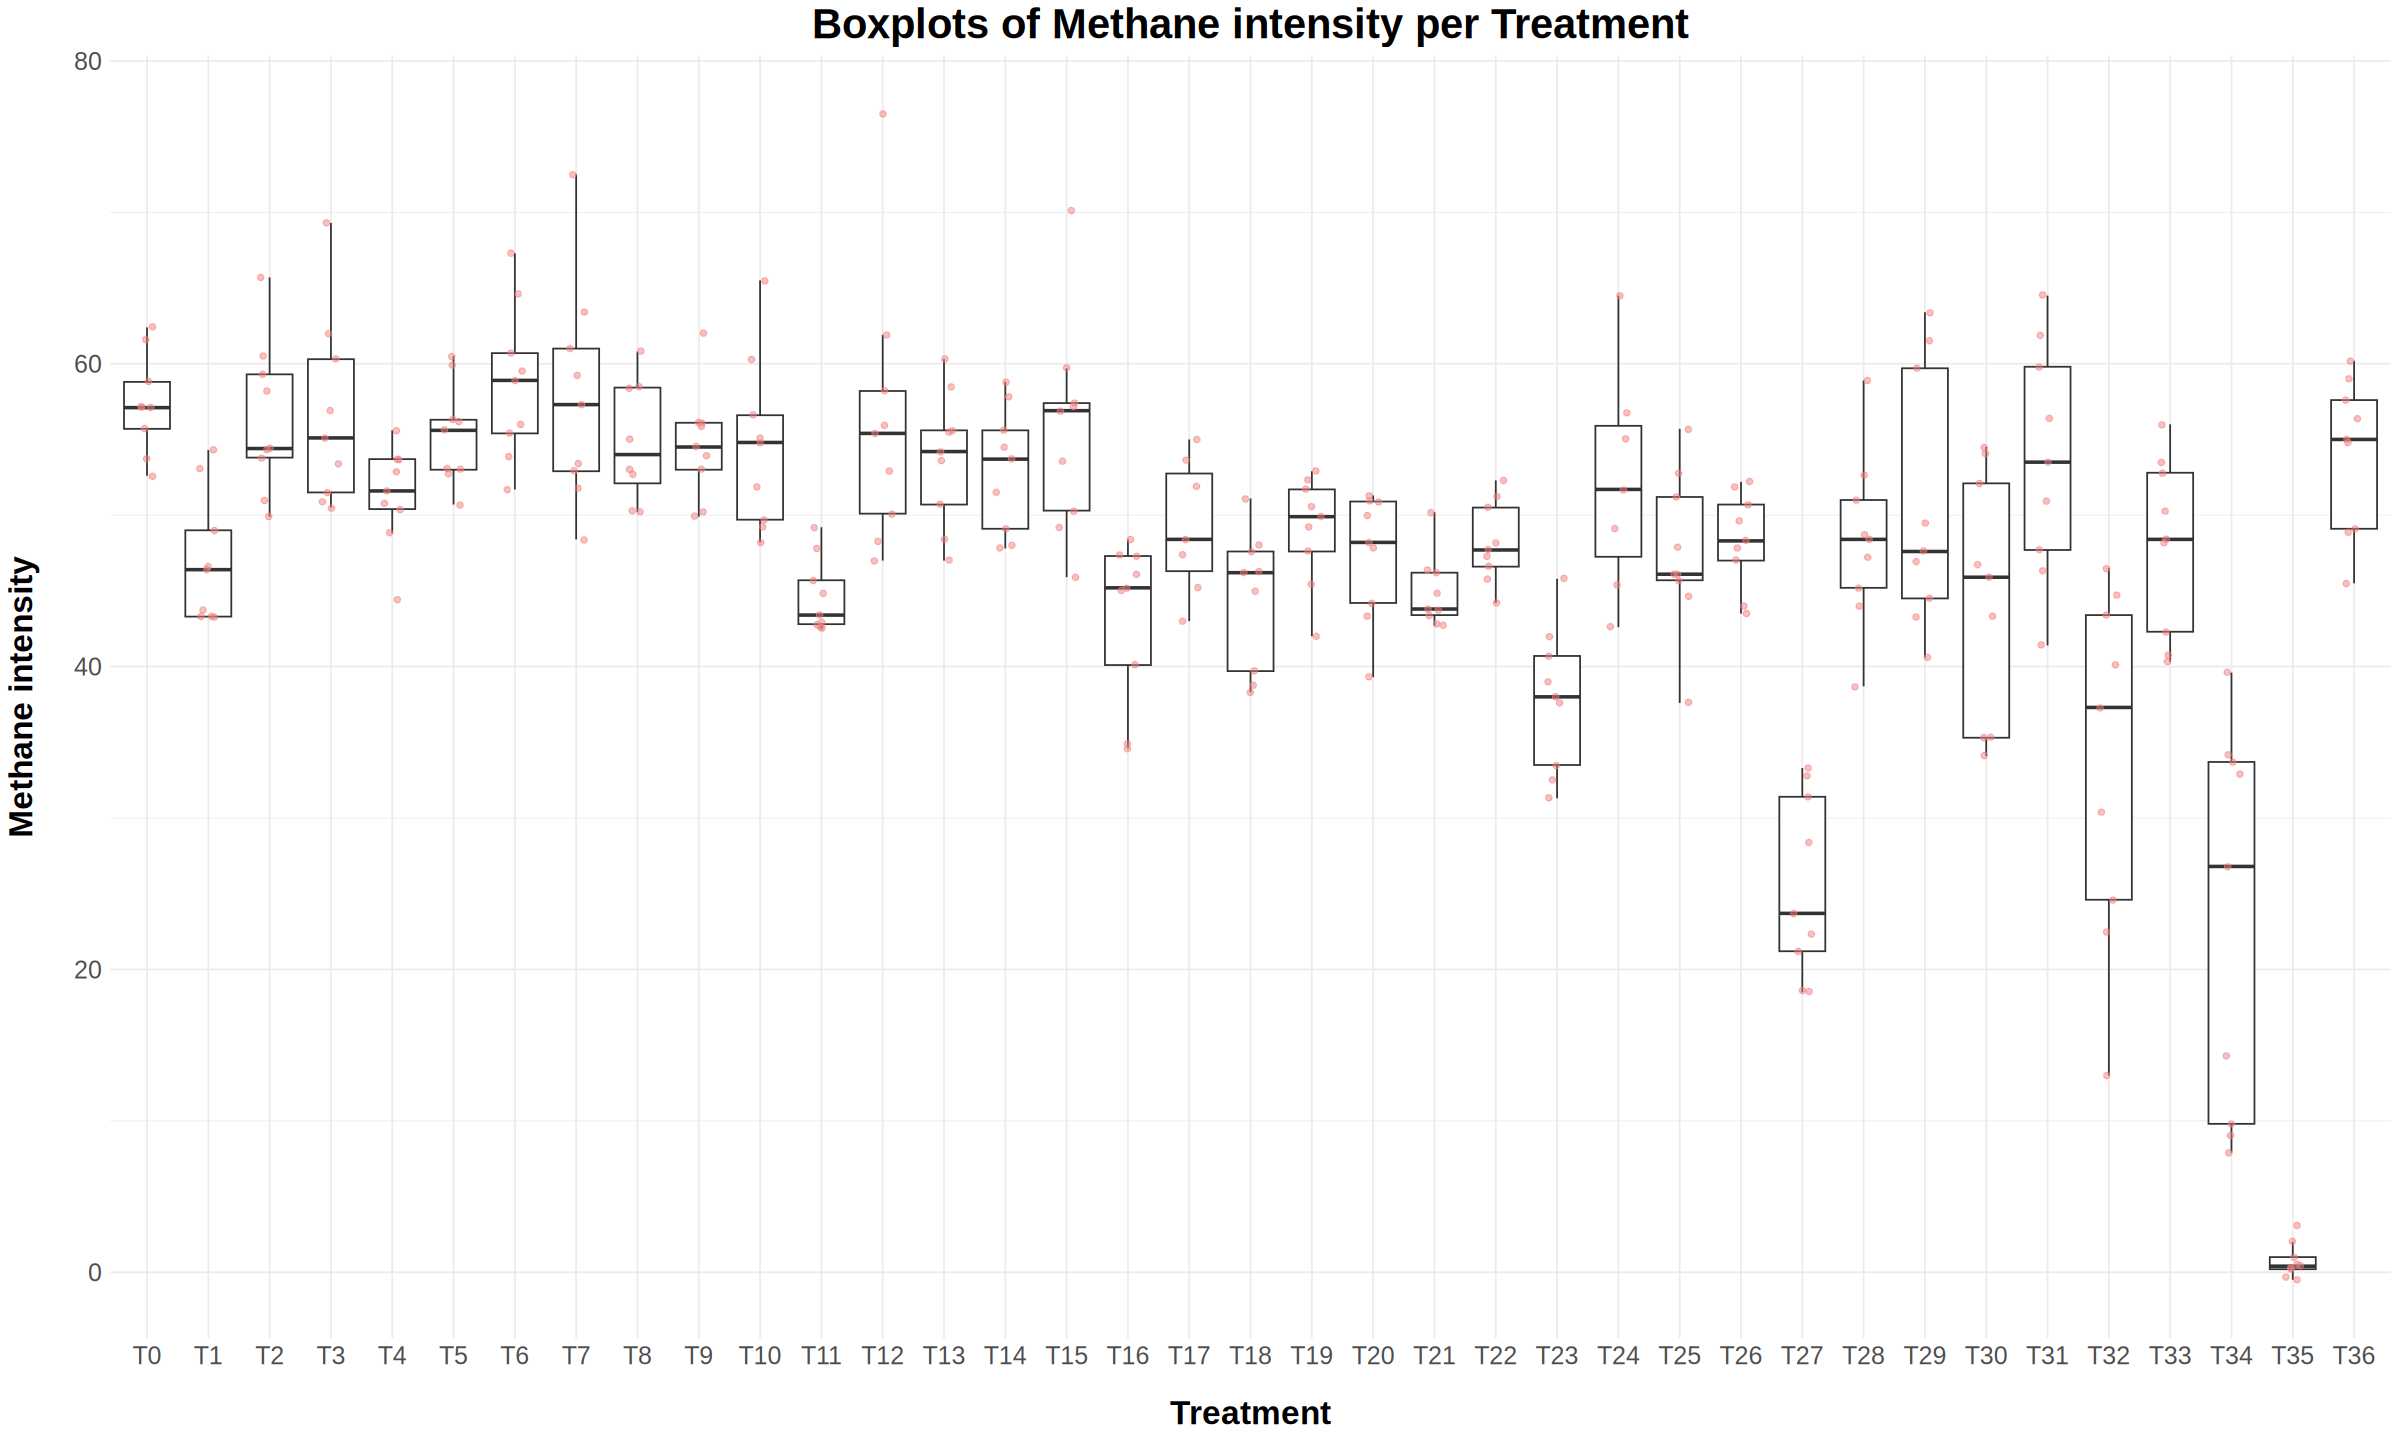

In [97]:
options(repr.plot.width=20, repr.plot.height=12)
ggplot(df, aes(x = Treatment, y = CH4_ml_g_DMD_24h)) +
      geom_boxplot(outlier.shape = NA) +
      geom_jitter(width = 0.15, alpha = 0.5, color = "lightcoral") +
      labs(title = "Boxplots of Methane intensity per Treatment", x = "Treatment", y = "Methane intensity") +
      theme_minimal() +
      theme(
        plot.title = element_text(size = 25, face = "bold", hjust = 0.5),
        axis.title.x = element_text(size = 20, face = "bold",  margin = margin(t = 20)),
        axis.title.y = element_text(size = 20, face = "bold",  margin = margin(r = 20)),
        axis.text.x = element_text(size = 15),
        axis.text.y = element_text(size = 15)
      )

## 4.3 Boxplot Blank

Warning message:
“Removed 9 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 9 rows containing missing values or values outside the scale range
(`geom_point()`).”


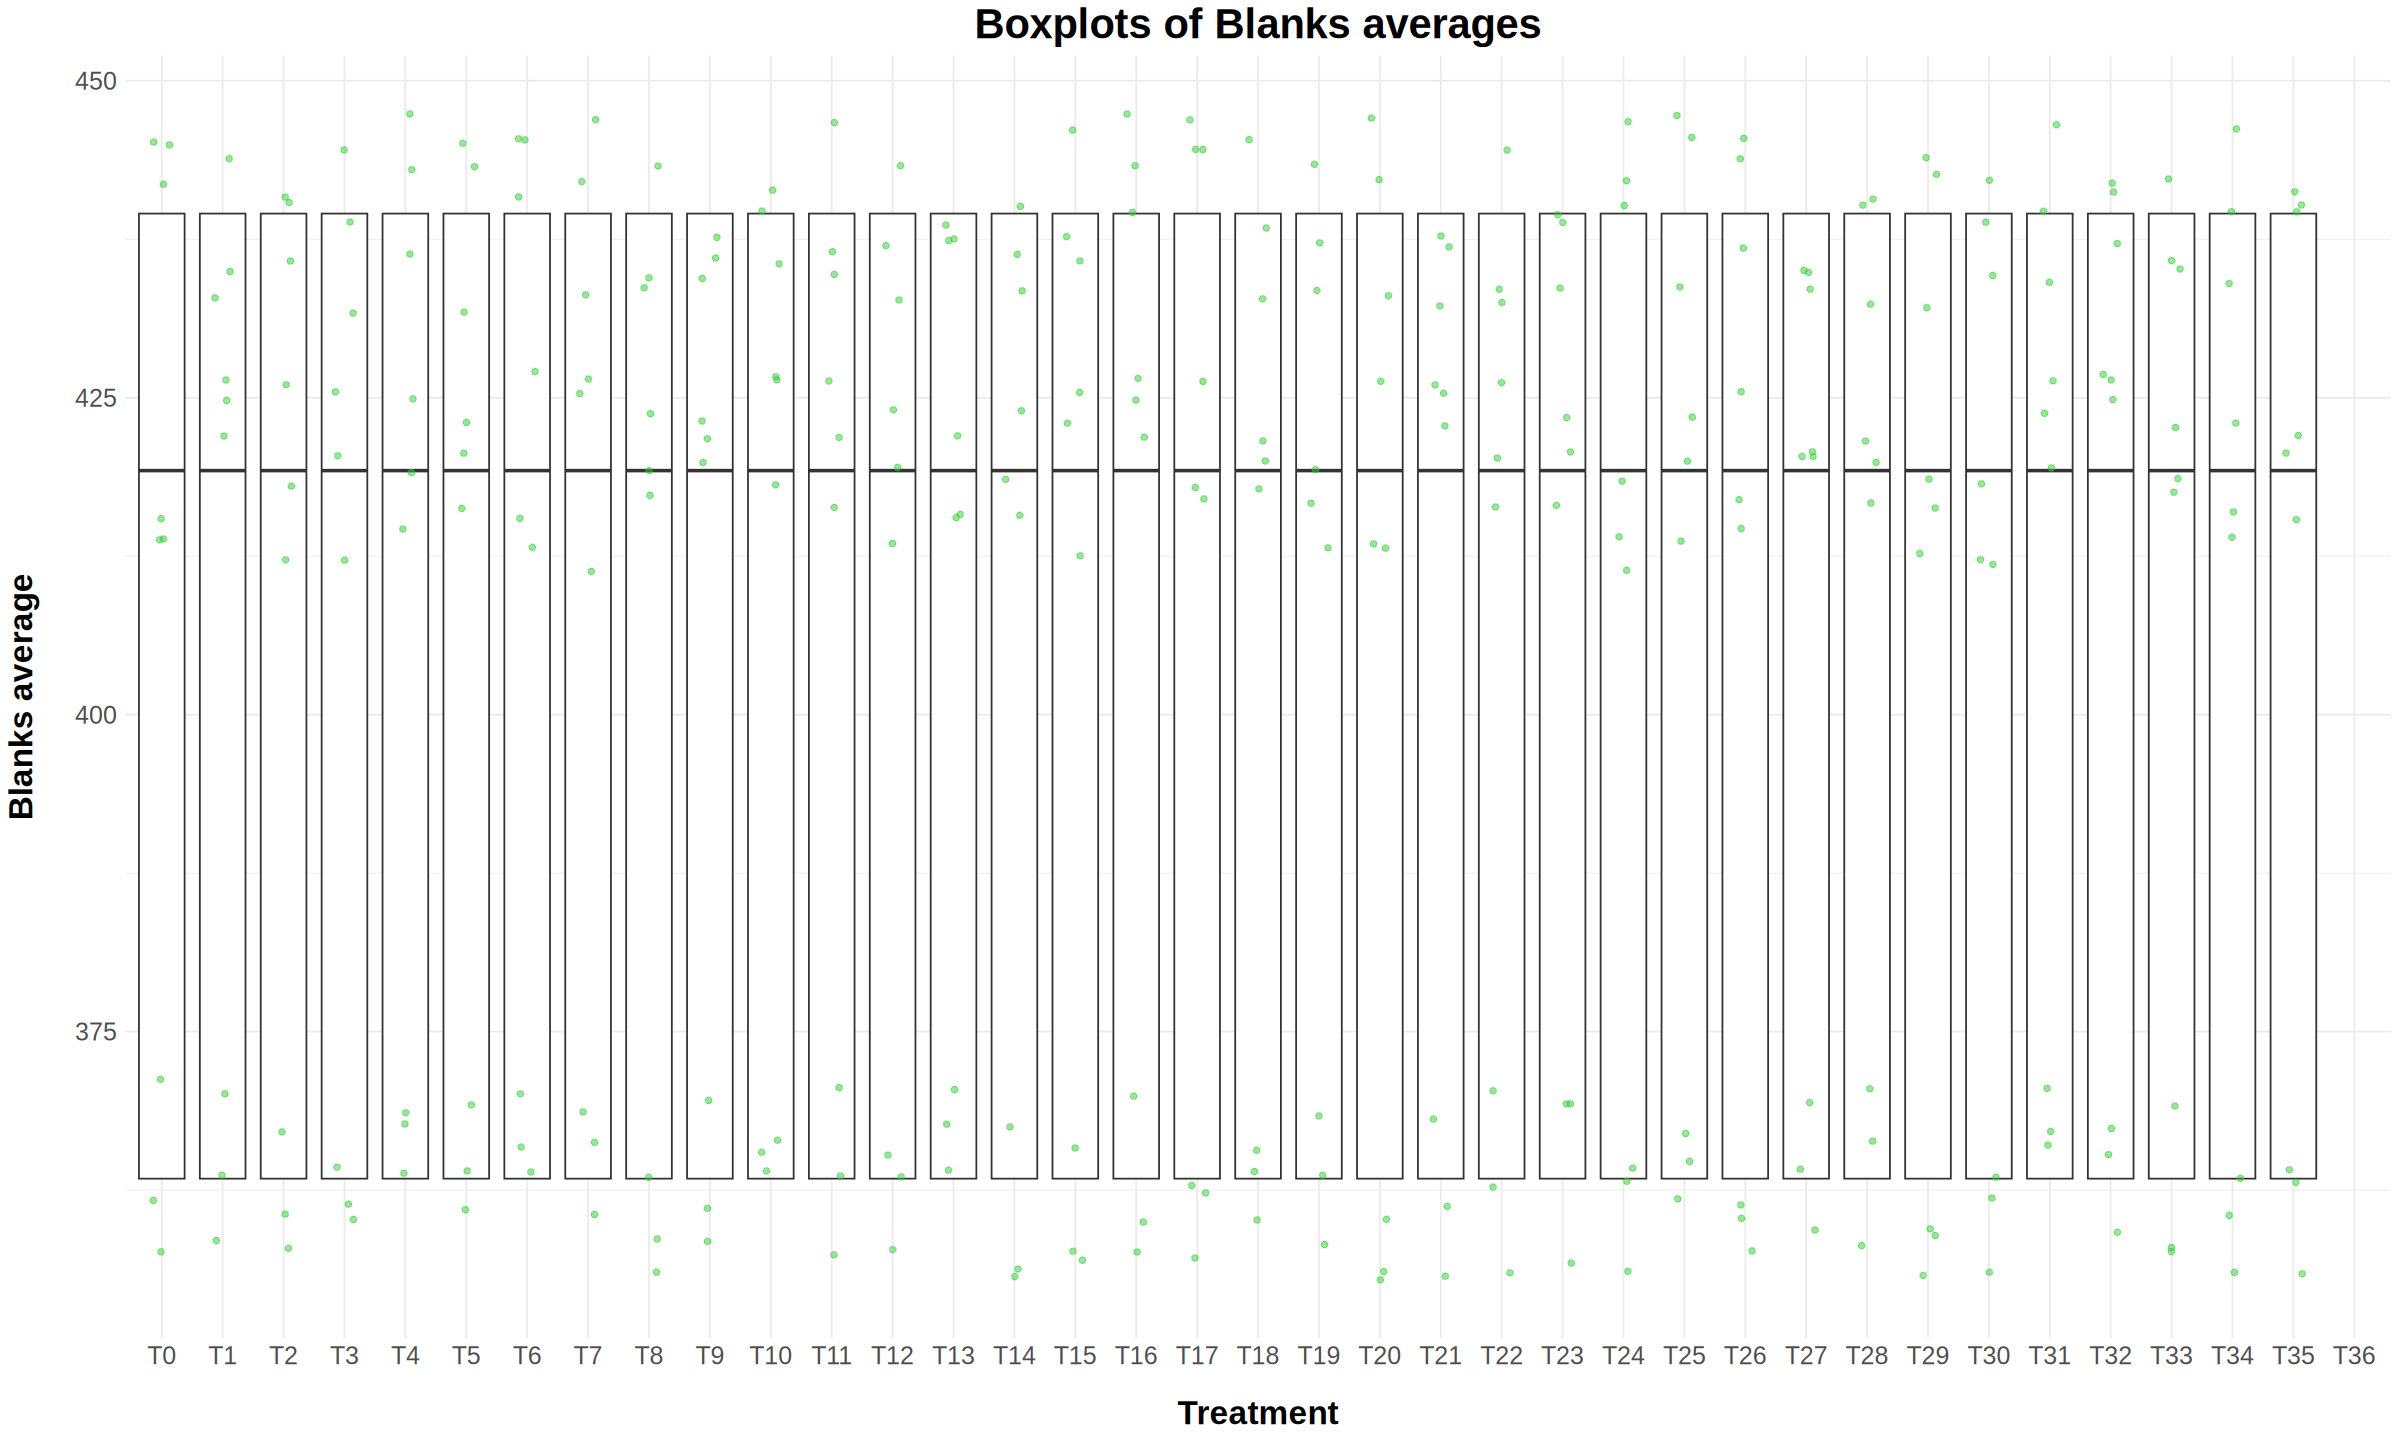

In [98]:
options(repr.plot.width=20, repr.plot.height=12)
ggplot(df, aes(x = Treatment, y = BLANK_24H_promedio_corrida_ppm )) +
      geom_boxplot(outlier.shape = NA) +
      geom_jitter(width = 0.15, alpha = 0.5, color = "limegreen") +
      labs(title = "Boxplots of Blanks averages", x = "Treatment", y = "Blanks average") +
      theme_minimal() +
      theme(
        plot.title = element_text(size = 25, face = "bold", hjust = 0.5),
        axis.title.x = element_text(size = 20, face = "bold",  margin = margin(t = 20)),
        axis.title.y = element_text(size = 20, face = "bold",  margin = margin(r = 20)),
        axis.text.x = element_text(size = 15),
        axis.text.y = element_text(size = 15)
      )

# 5.0  Analysis of Variance

# 5.1 TDDM %

### 5.1.1 One way ANOVA

Linear model with treatments as fixed effect

Hypotesis

Ho : means among groups are equal

Ha : means among groups are significantly DIFFERENT

In [128]:
model_tddm <- lm(TDDM_percentage ~ factor(Treatment), data = df2)
anova(model_tddm)

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
factor(Treatment),29,916.1609,31.59176,2.641227,3.053371e-05
Residuals,235,2810.8382,11.96101,NA,NA


p-value < 0.05. Ho is rejected. Ha accepted: Means among groups are significantly different.

### 5.1.2 Normality test

Hypotesis

Ho: The data follow a normal distribution

Ha : The data DO NOT follow a normal distribution

In [129]:
shapiro.test(residuals(model_tddm))


	Shapiro-Wilk normality test

data:  residuals(model_tddm)
W = 0.97157, p-value = 3.964e-05


p-value < 0.05. Ho is rejected. Ha is accepted: The data DO NOT follow a normal distribution.

#### 5.1.2.1 Graphics

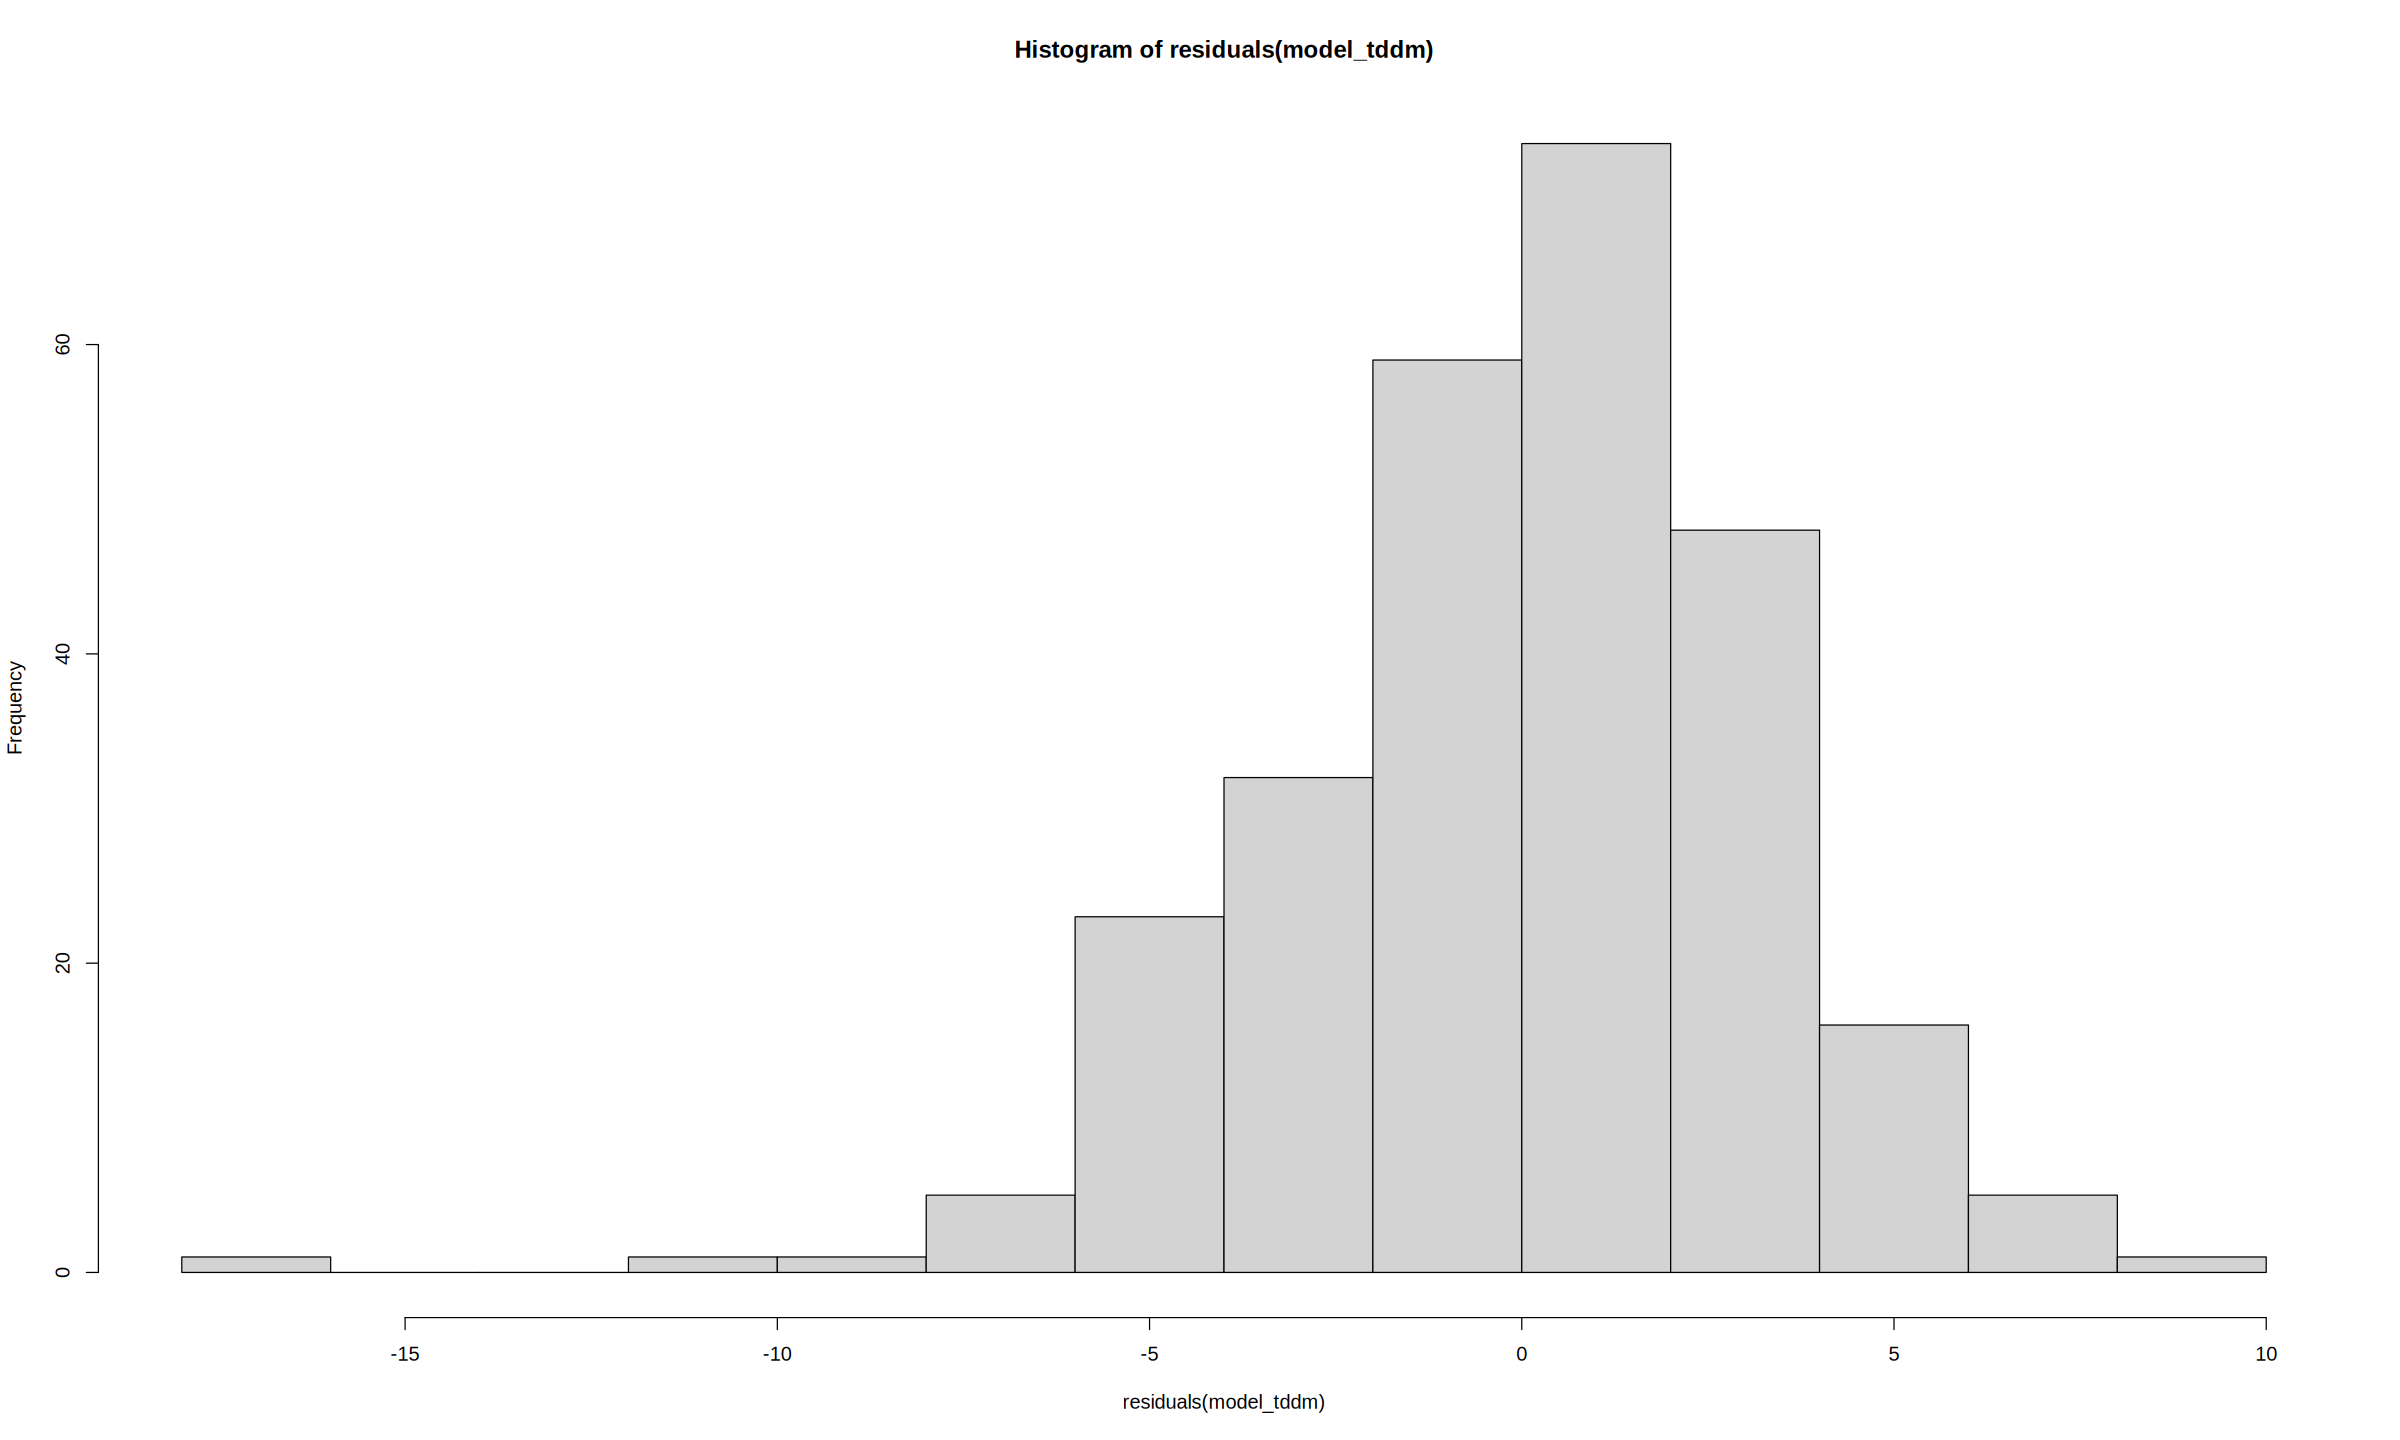

In [130]:
hist(residuals(model_tddm))

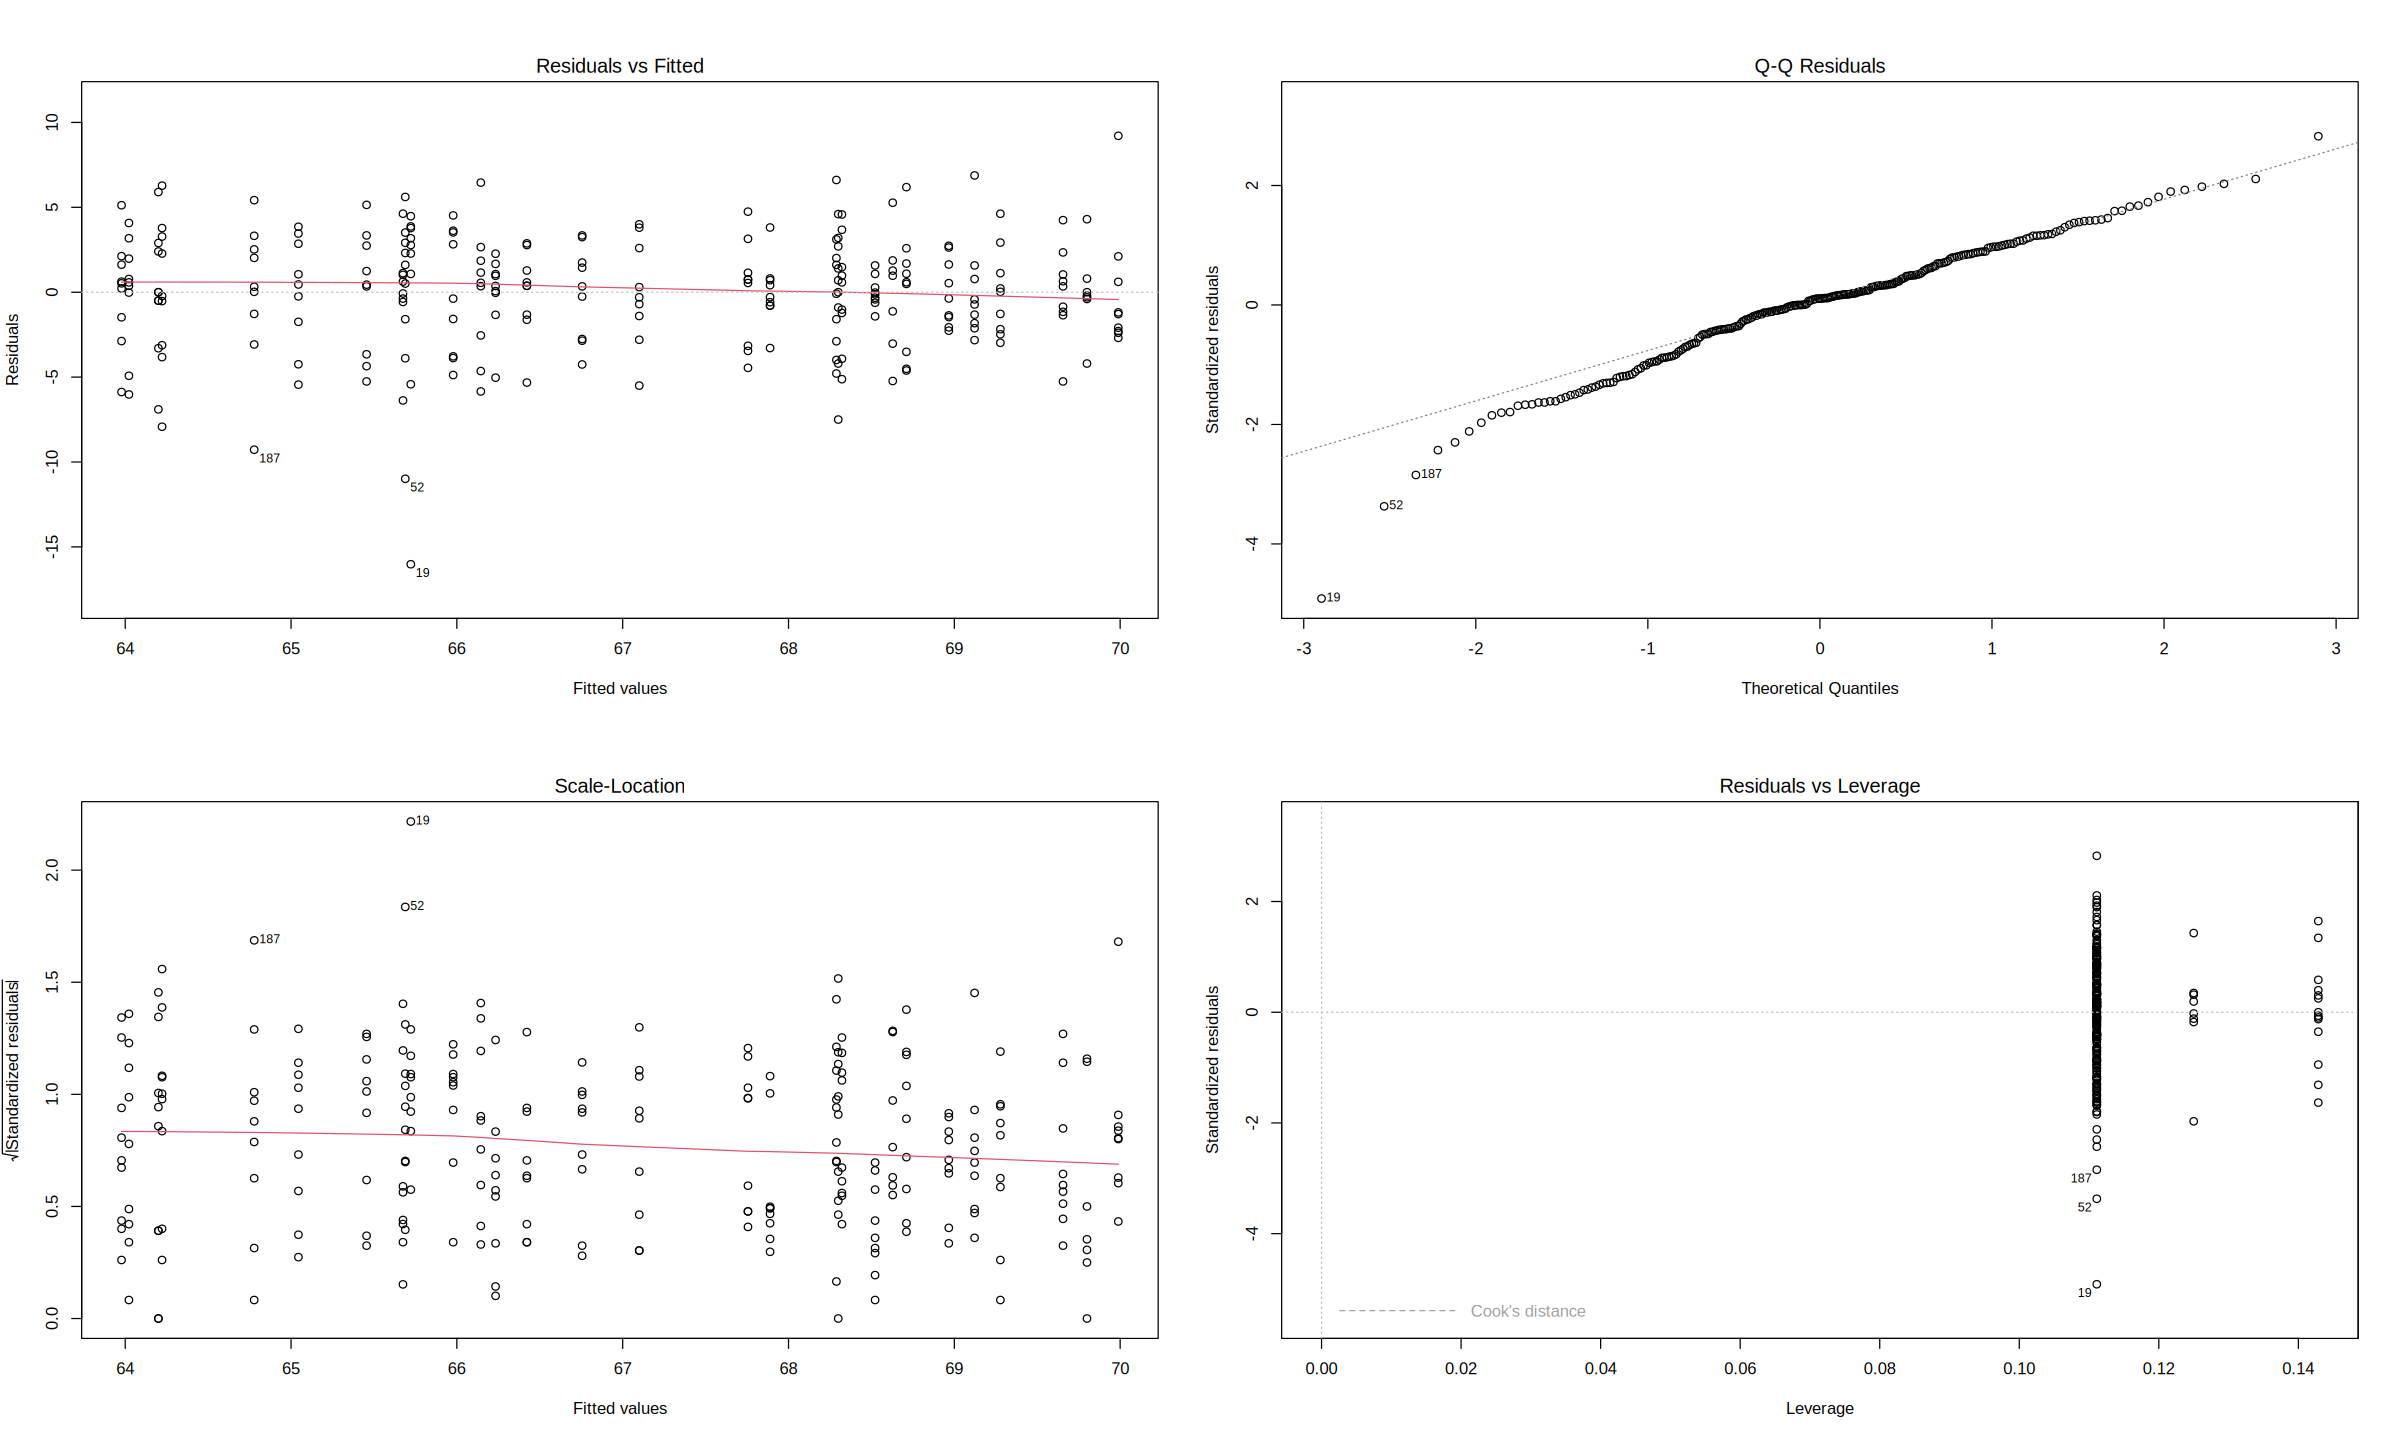

In [131]:
par(mfrow = c(2,2))
plot(model_tddm)

### 5.1.3 Homoscedasticity

Ho : All group variances are equal

Ha : At least one variance is DIFFERENT

In [132]:
bartlett.test(TDDM_percentage~ Treatment,data=df)


	Bartlett test of homogeneity of variances

data:  TDDM_percentage by Treatment
Bartlett's K-squared = 54.476, df = 36, p-value = 0.0248


p-value < 0.05. Ho is rejected. Ha is accepted: The variance across the groups is NOT homogeneous.

## 5.1.4 Desicion

Based on the tests for normality and homoscedasticity, the TDDM% data **do not meet the parametric assumptions** required for an analysis of variance. To compare the groups, nonparametric tests, such as the **Kruskal-Wallis** test, must be applied to the data.

# 6.0 Kruskal-Wallis nonparametric test

## 6.1 TDDM%

### 6.1.1 Statistical test

Hypotesis

Ho : means among groups are equal

Ha : means among groups are DIFFERENT

In [141]:
kruskal.test(TDDM_percentage ~ Treatment, data = df)


	Kruskal-Wallis rank sum test

data:  TDDM_percentage by Treatment
Kruskal-Wallis chi-squared = 128.55, df = 36, p-value = 2.52e-12


p-value < 0.05. Ho is rejected. Ha accepted: Means among groups are different.

### 6.1.2 Dunn’s post-hoc test

In [164]:
dunn_results <- df %>%
  dunn_test(
    TDDM_percentage ~ Treatment,
    p.adjust.method = "holm"
  )

In [154]:
p_values <- dunn_results$p.adj

names(p_values) <- paste(
  dunn_results$group1,
  dunn_results$group2,
  sep = "-"
)

letters <- multcompLetters(p_values)

letters_df <- data.frame(
  Treatment = names(letters$Letters),
  letter = letters$Letters
)

letters_df

,Treatment,letter
,<chr>,<chr>
T0,T0,a
T1,T1,bc
T2,T2,abcd
T3,T3,bcd
T4,T4,abd
T5,T5,abcd
T6,T6,bcd
T7,T7,bcd
T8,T8,bcd


### 6.1.3 Boxplot by statistical groups

In [155]:
letters_df <- df %>%
  group_by(Treatment) %>%
  summarise(
    mean = mean(
      TDDM_percentage,
      na.rm = TRUE
    )
  ) %>%
  left_join(
    letters_df,
    by = "Treatment"
  ) %>%
  arrange(letter, desc(mean))

In [168]:
letters_df <- letters_df %>%
  mutate(
    mean = round(mean, 2)
  ) %>%
  arrange(letter, desc(mean))

head(letters_df)

Treatment,mean,letter
<chr>,<dbl>,<chr>
T0,77.90,a
T5,67.10,abcd
T2,66.82,abcd
T29,66.76,abcd
T14,65.98,abcd
T12,65.72,abcd


In [166]:
df_plot <- df %>%
  left_join(
    letters_df %>% select(Treatment, letter),
    by = "Treatment"
  )

Warning message:
“Removed 5 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_point()`).”


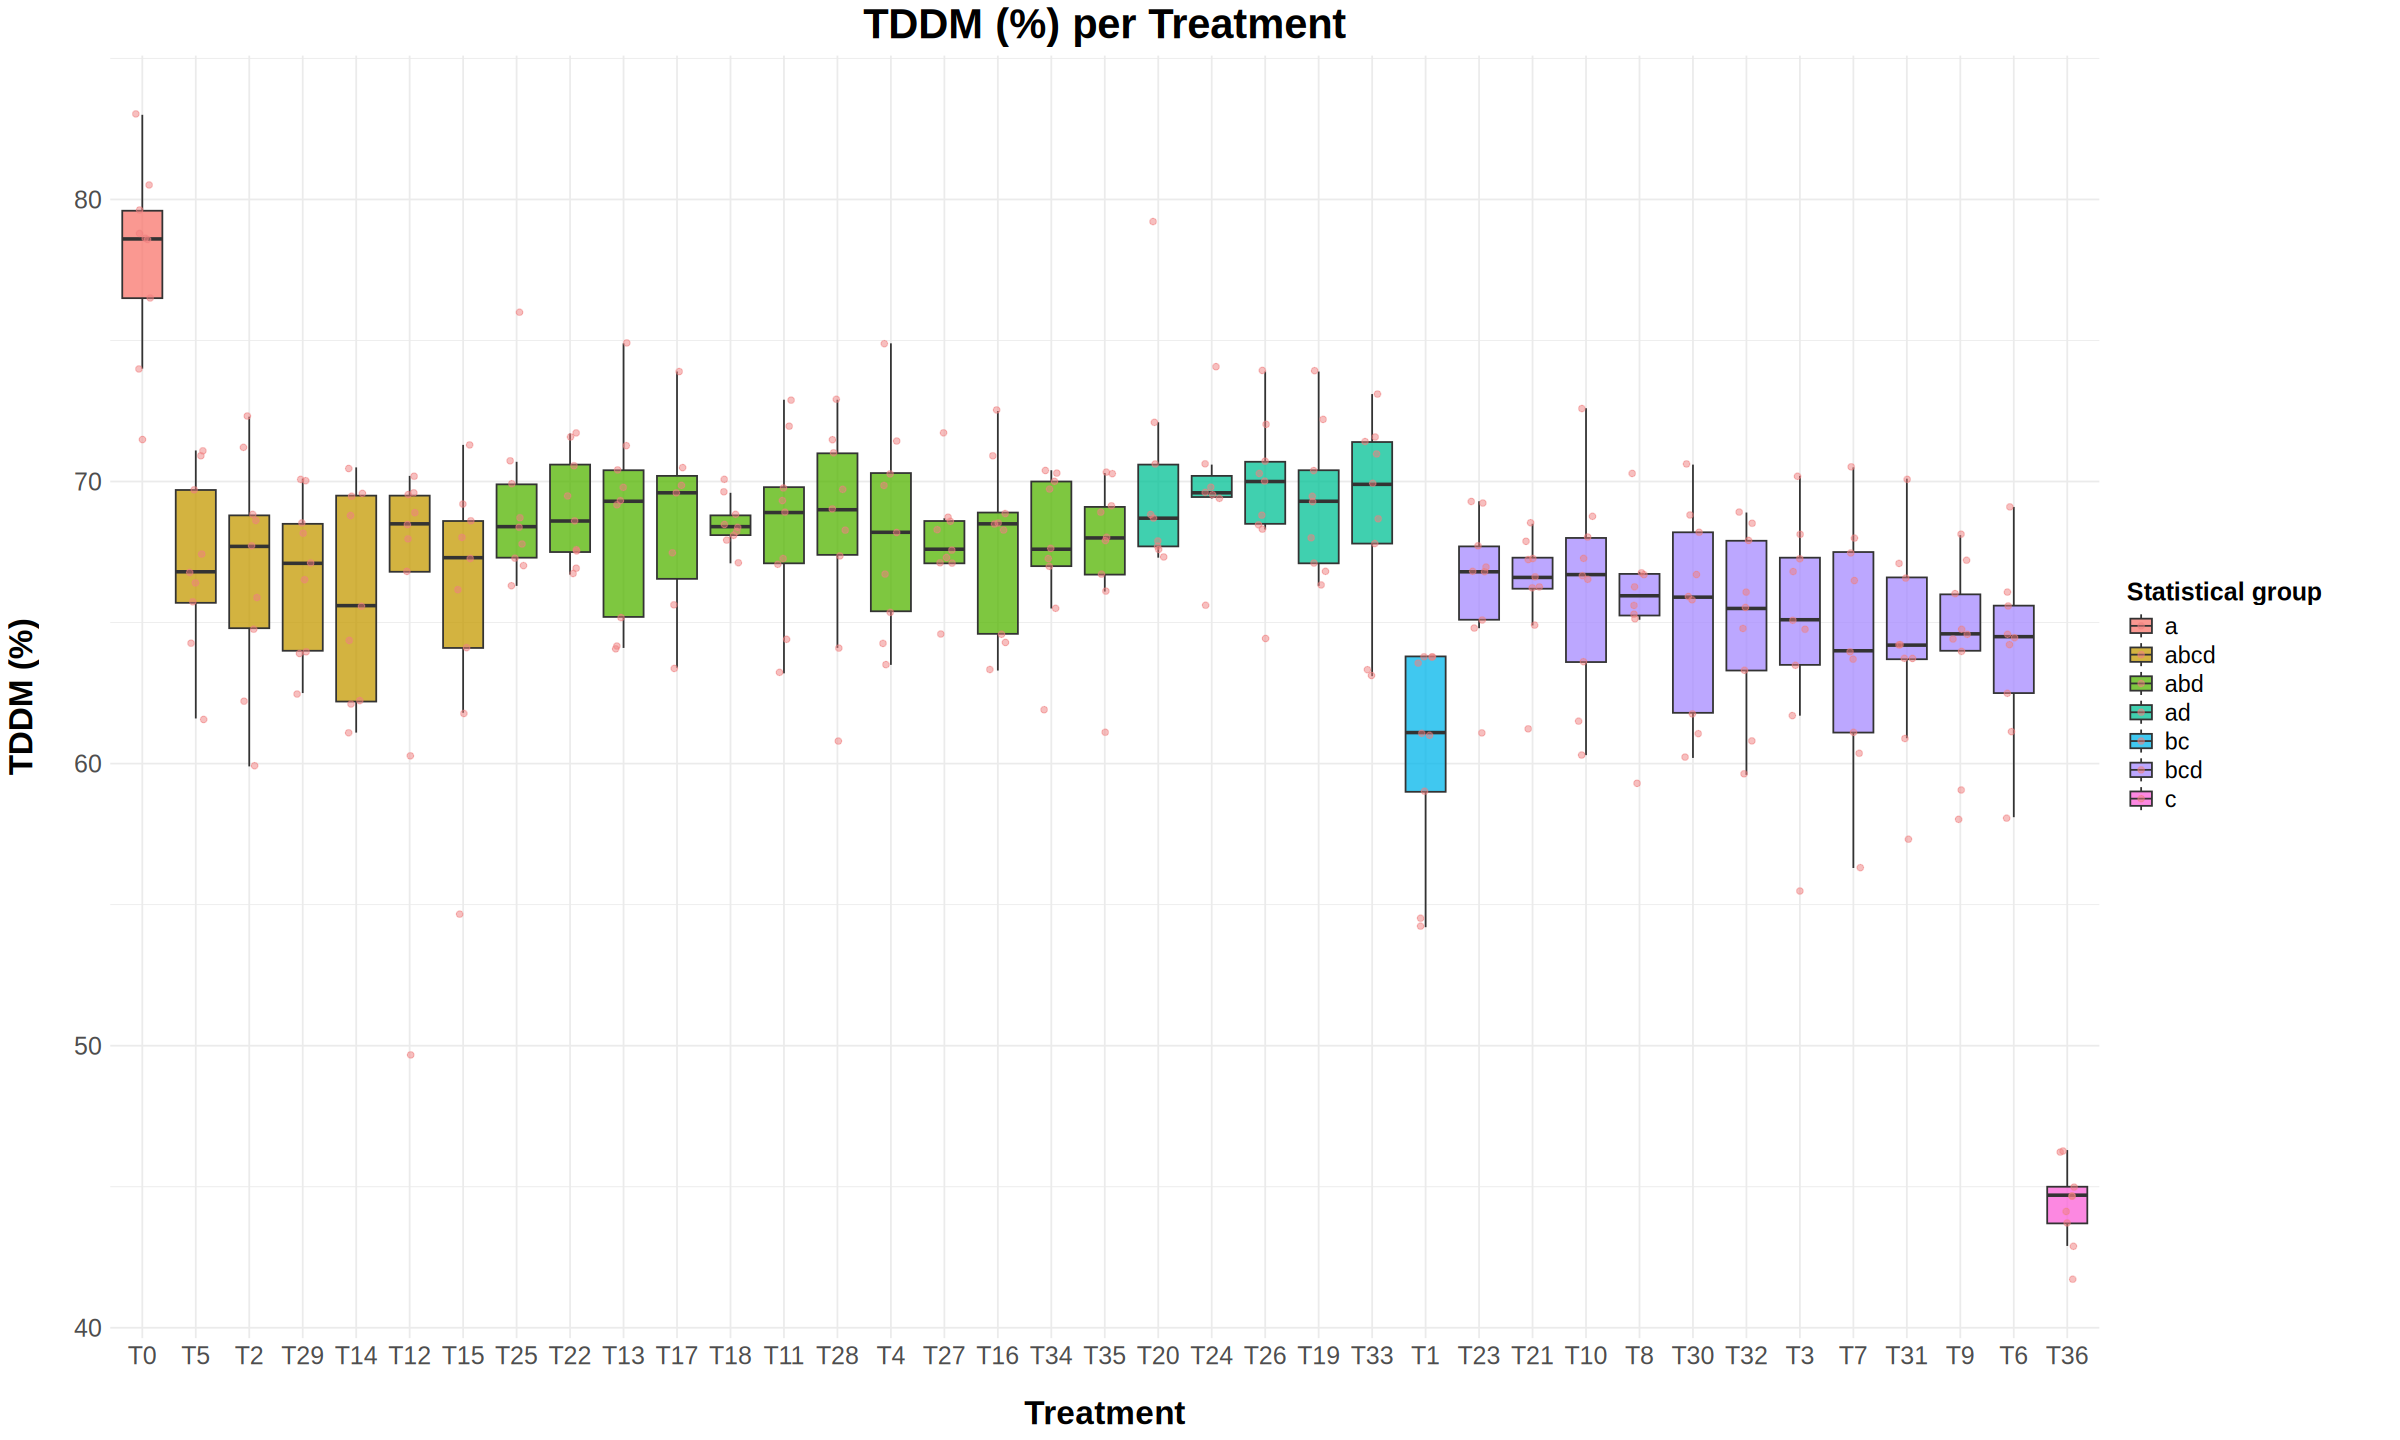

In [167]:
options(repr.plot.width = 20, repr.plot.height = 12)

# ============================================================
# 1. Sort treatments by statistical group and then by mean
# ============================================================

letters_df <- letters_df %>%
  arrange(letter, desc(mean))

# ============================================================
# 2. Add the statistical group to the original dataset
# ============================================================

df_plot <- df %>%
  left_join(
    letters_df %>%
      select(Treatment, letter),
    by = "Treatment"
  )

# ============================================================
# 3. Set the treatment order according to letters_df
# ============================================================

df_plot$Treatment <- factor(
  df_plot$Treatment,
  levels = letters_df$Treatment
)

# ============================================================
# 4. Create the plot
# ============================================================

ggplot(
  df_plot,
  aes(
    x = Treatment,
    y = TDDM_percentage,
    fill = letter
  )
) +

  # Boxplots
  geom_boxplot(
    outlier.shape = NA,
    alpha = 0.75
  ) +

  # Individual observations
  geom_jitter(
    width = 0.15,
    alpha = 0.5,
    color = "lightcoral"
  ) +

  # Labels
  labs(
    title = "TDDM (%) per Treatment",
    x = "Treatment",
    y = "TDDM (%)",
    fill = "Statistical group"
  ) +

  # Plot theme
  theme_minimal() +

  theme(
    plot.title = element_text(
      size = 25,
      face = "bold",
      hjust = 0.5
    ),

    axis.title.x = element_text(
      size = 20,
      face = "bold",
      margin = margin(t = 20)
    ),

    axis.title.y = element_text(
      size = 20,
      face = "bold",
      margin = margin(r = 20)
    ),

    axis.text.x = element_text(
      size = 15
    ),

    axis.text.y = element_text(
      size = 15
    ),

    legend.title = element_text(
      size = 15,
      face = "bold"
    ),

    legend.text = element_text(
      size = 14
    )
  )

Warning message:
“Removed 5 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_point()`).”


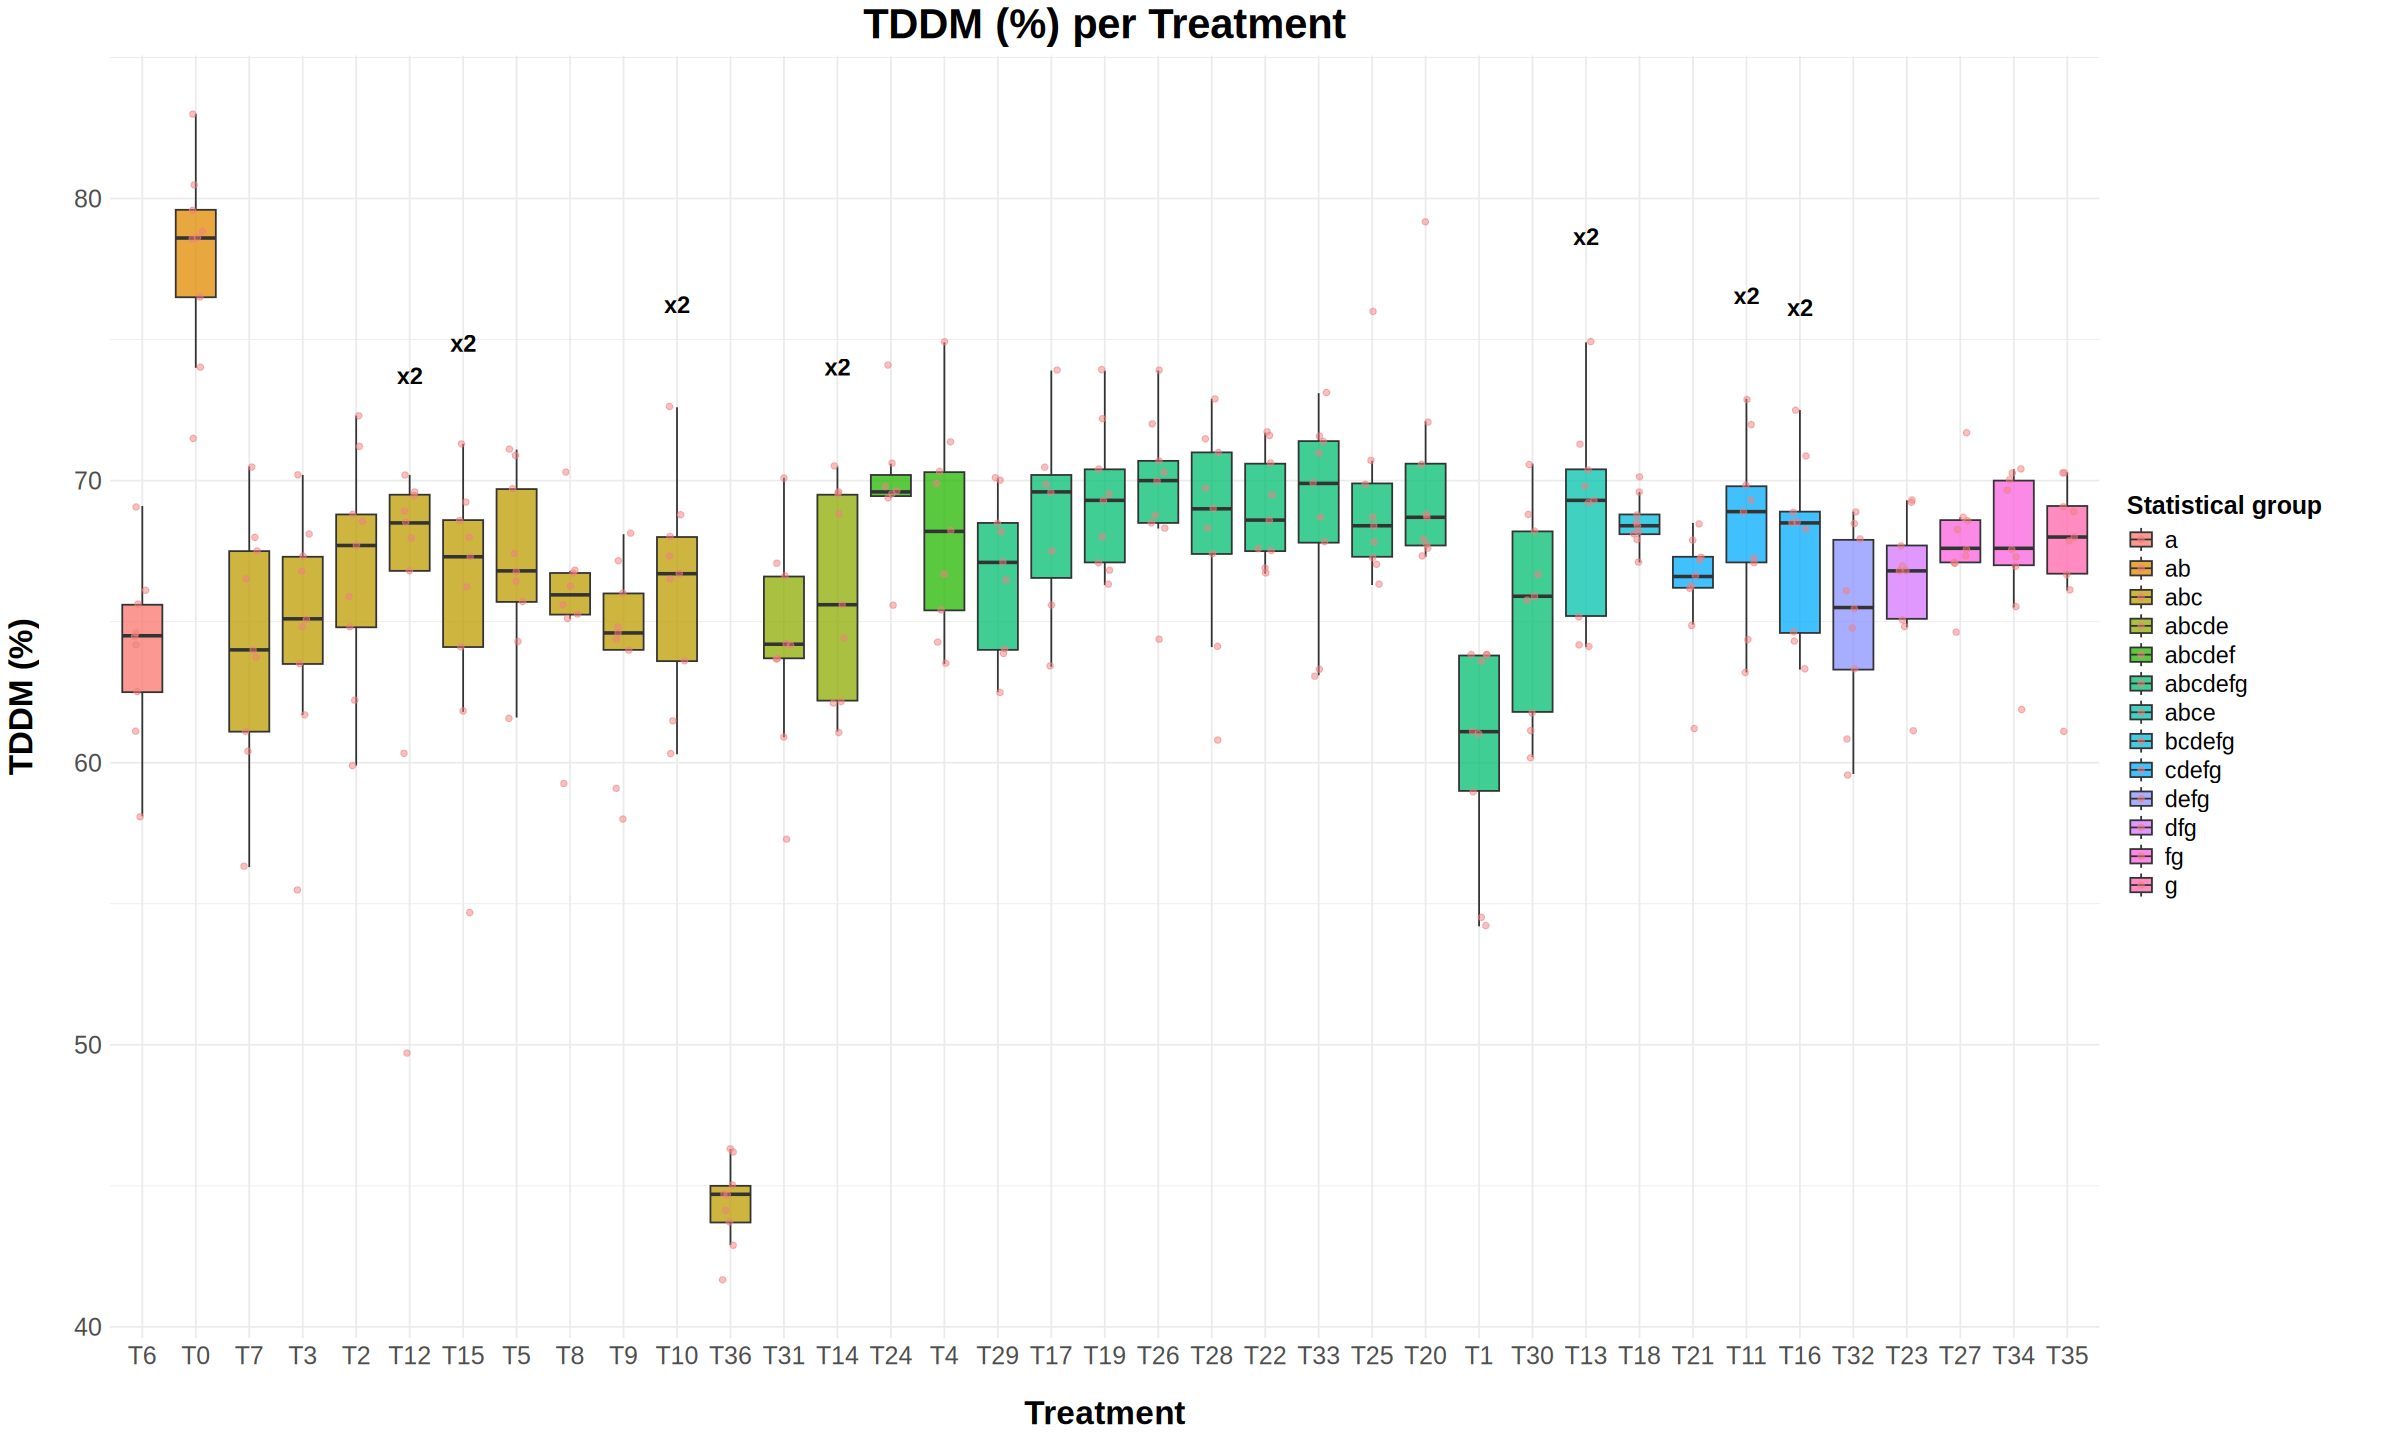

In [180]:
options(repr.plot.width = 20, repr.plot.height = 12)

# ============================================================
# 1. Treatments where "x2" should be displayed
# ============================================================

x2_treatments <- c("T10", "T11", "T12", "T13", "T14", "T15", "T16")

# ============================================================
# 2. Sort treatments by statistical group and then by mean
# ============================================================

letters_df <- letters_df %>%
  arrange(letter, desc(mean))

# ============================================================
# 3. Add the statistical group to the original dataset
# ============================================================

df_plot <- df %>%
  left_join(
    letters_df %>%
      select(Treatment, letter),
    by = "Treatment"
  )

# ============================================================
# 4. Set the treatment order according to letters_df
# ============================================================

df_plot$Treatment <- factor(
  df_plot$Treatment,
  levels = letters_df$Treatment
)

# ============================================================
# 5. Create positions for the "x2" labels
# ============================================================

x2_labels <- df_plot %>%
  group_by(Treatment) %>%
  summarise(
    y_position = max(TDDM_percentage, na.rm = TRUE) * 1.05,
    .groups = "drop"
  ) %>%
  filter(Treatment %in% x2_treatments)

# ============================================================
# 6. Create the plot
# ============================================================

ggplot(
  df_plot,
  aes(
    x = Treatment,
    y = TDDM_percentage,
    fill = letter
  )
) +

  # Boxplots
  geom_boxplot(
    outlier.shape = NA,
    alpha = 0.75
  ) +

  # Individual observations
  geom_jitter(
    width = 0.15,
    alpha = 0.5,
    color = "lightcoral"
  ) +

  # Add "x2" above selected treatments
  geom_text(
    data = x2_labels,
    aes(
      x = Treatment,
      y = y_position,
      label = "x2"
    ),
    inherit.aes = FALSE,
    size = 5,
    fontface = "bold"
  ) +

  # Labels
  labs(
    title = "TDDM (%) per Treatment",
    x = "Treatment",
    y = "TDDM (%)",
    fill = "Statistical group"
  ) +

  # Plot theme
  theme_minimal() +

  theme(
    plot.title = element_text(
      size = 25,
      face = "bold",
      hjust = 0.5
    ),

    axis.title.x = element_text(
      size = 20,
      face = "bold",
      margin = margin(t = 20)
    ),

    axis.title.y = element_text(
      size = 20,
      face = "bold",
      margin = margin(r = 20)
    ),

    axis.text.x = element_text(
      size = 15
    ),

    axis.text.y = element_text(
      size = 15
    ),

    legend.title = element_text(
      size = 15,
      face = "bold"
    ),

    legend.text = element_text(
      size = 14
    )
  )

In [181]:
ggsave(
  filename = "tddm_treatments.png",
  dpi = 300,
  width = 20,
  height = 12,
  units = "in"
)

Warning message:
“Removed 5 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_point()`).”


## 6.2 Methane Intensity

### 6.2.1 Statistical test

Hypotesis

Ho : means among groups are equal

Ha : means among groups are DIFFERENT

In [169]:
kruskal.test(CH4_ml_g_DMD_24h ~ Treatment, data = df)


	Kruskal-Wallis rank sum test

data:  CH4_ml_g_DMD_24h by Treatment
Kruskal-Wallis chi-squared = 212.53, df = 36, p-value < 2.2e-16


p-value < 0.05. Ho is rejected. Ha accepted: Means among groups are different.

### 6.1.2 Dunn’s post-hoc test

In [170]:
dunn_results <- df %>%
  dunn_test(
    CH4_ml_g_DMD_24h ~ Treatment,
    p.adjust.method = "holm"
  )

In [171]:
p_values <- dunn_results$p.adj

names(p_values) <- paste(
  dunn_results$group1,
  dunn_results$group2,
  sep = "-"
)

letters <- multcompLetters(p_values)

letters_df <- data.frame(
  Treatment = names(letters$Letters),
  letter = letters$Letters
)

letters_df

,Treatment,letter
,<chr>,<chr>
T0,T0,ab
T1,T1,abcdefg
T2,T2,abc
T3,T3,abc
T4,T4,abcdef
T5,T5,abc
T6,T6,a
T7,T7,abc
T8,T8,abc


### 6.1.3 Boxplot by statistical groups

In [172]:
letters_df <- df %>%
  group_by(Treatment) %>%
  summarise(
    mean = mean(
      CH4_ml_g_DMD_24h,
      na.rm = TRUE
    )
  ) %>%
  left_join(
    letters_df,
    by = "Treatment"
  ) %>%
  arrange(letter, desc(mean))

In [173]:
letters_df <- letters_df %>%
  mutate(
    mean = round(mean, 2)
  ) %>%
  arrange(letter, desc(mean))

head(letters_df)

Treatment,mean,letter
<chr>,<dbl>,<chr>
T6,58.67,a
T0,57.36,ab
T7,57.77,abc
T3,56.66,abc
T2,56.34,abc
T12,56.24,abc


In [ ]:
df_plot <- df %>%
  left_join(
    letters_df %>% select(Treatment, letter),
    by = "Treatment"
  )

Warning message:
“Removed 5 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_point()`).”


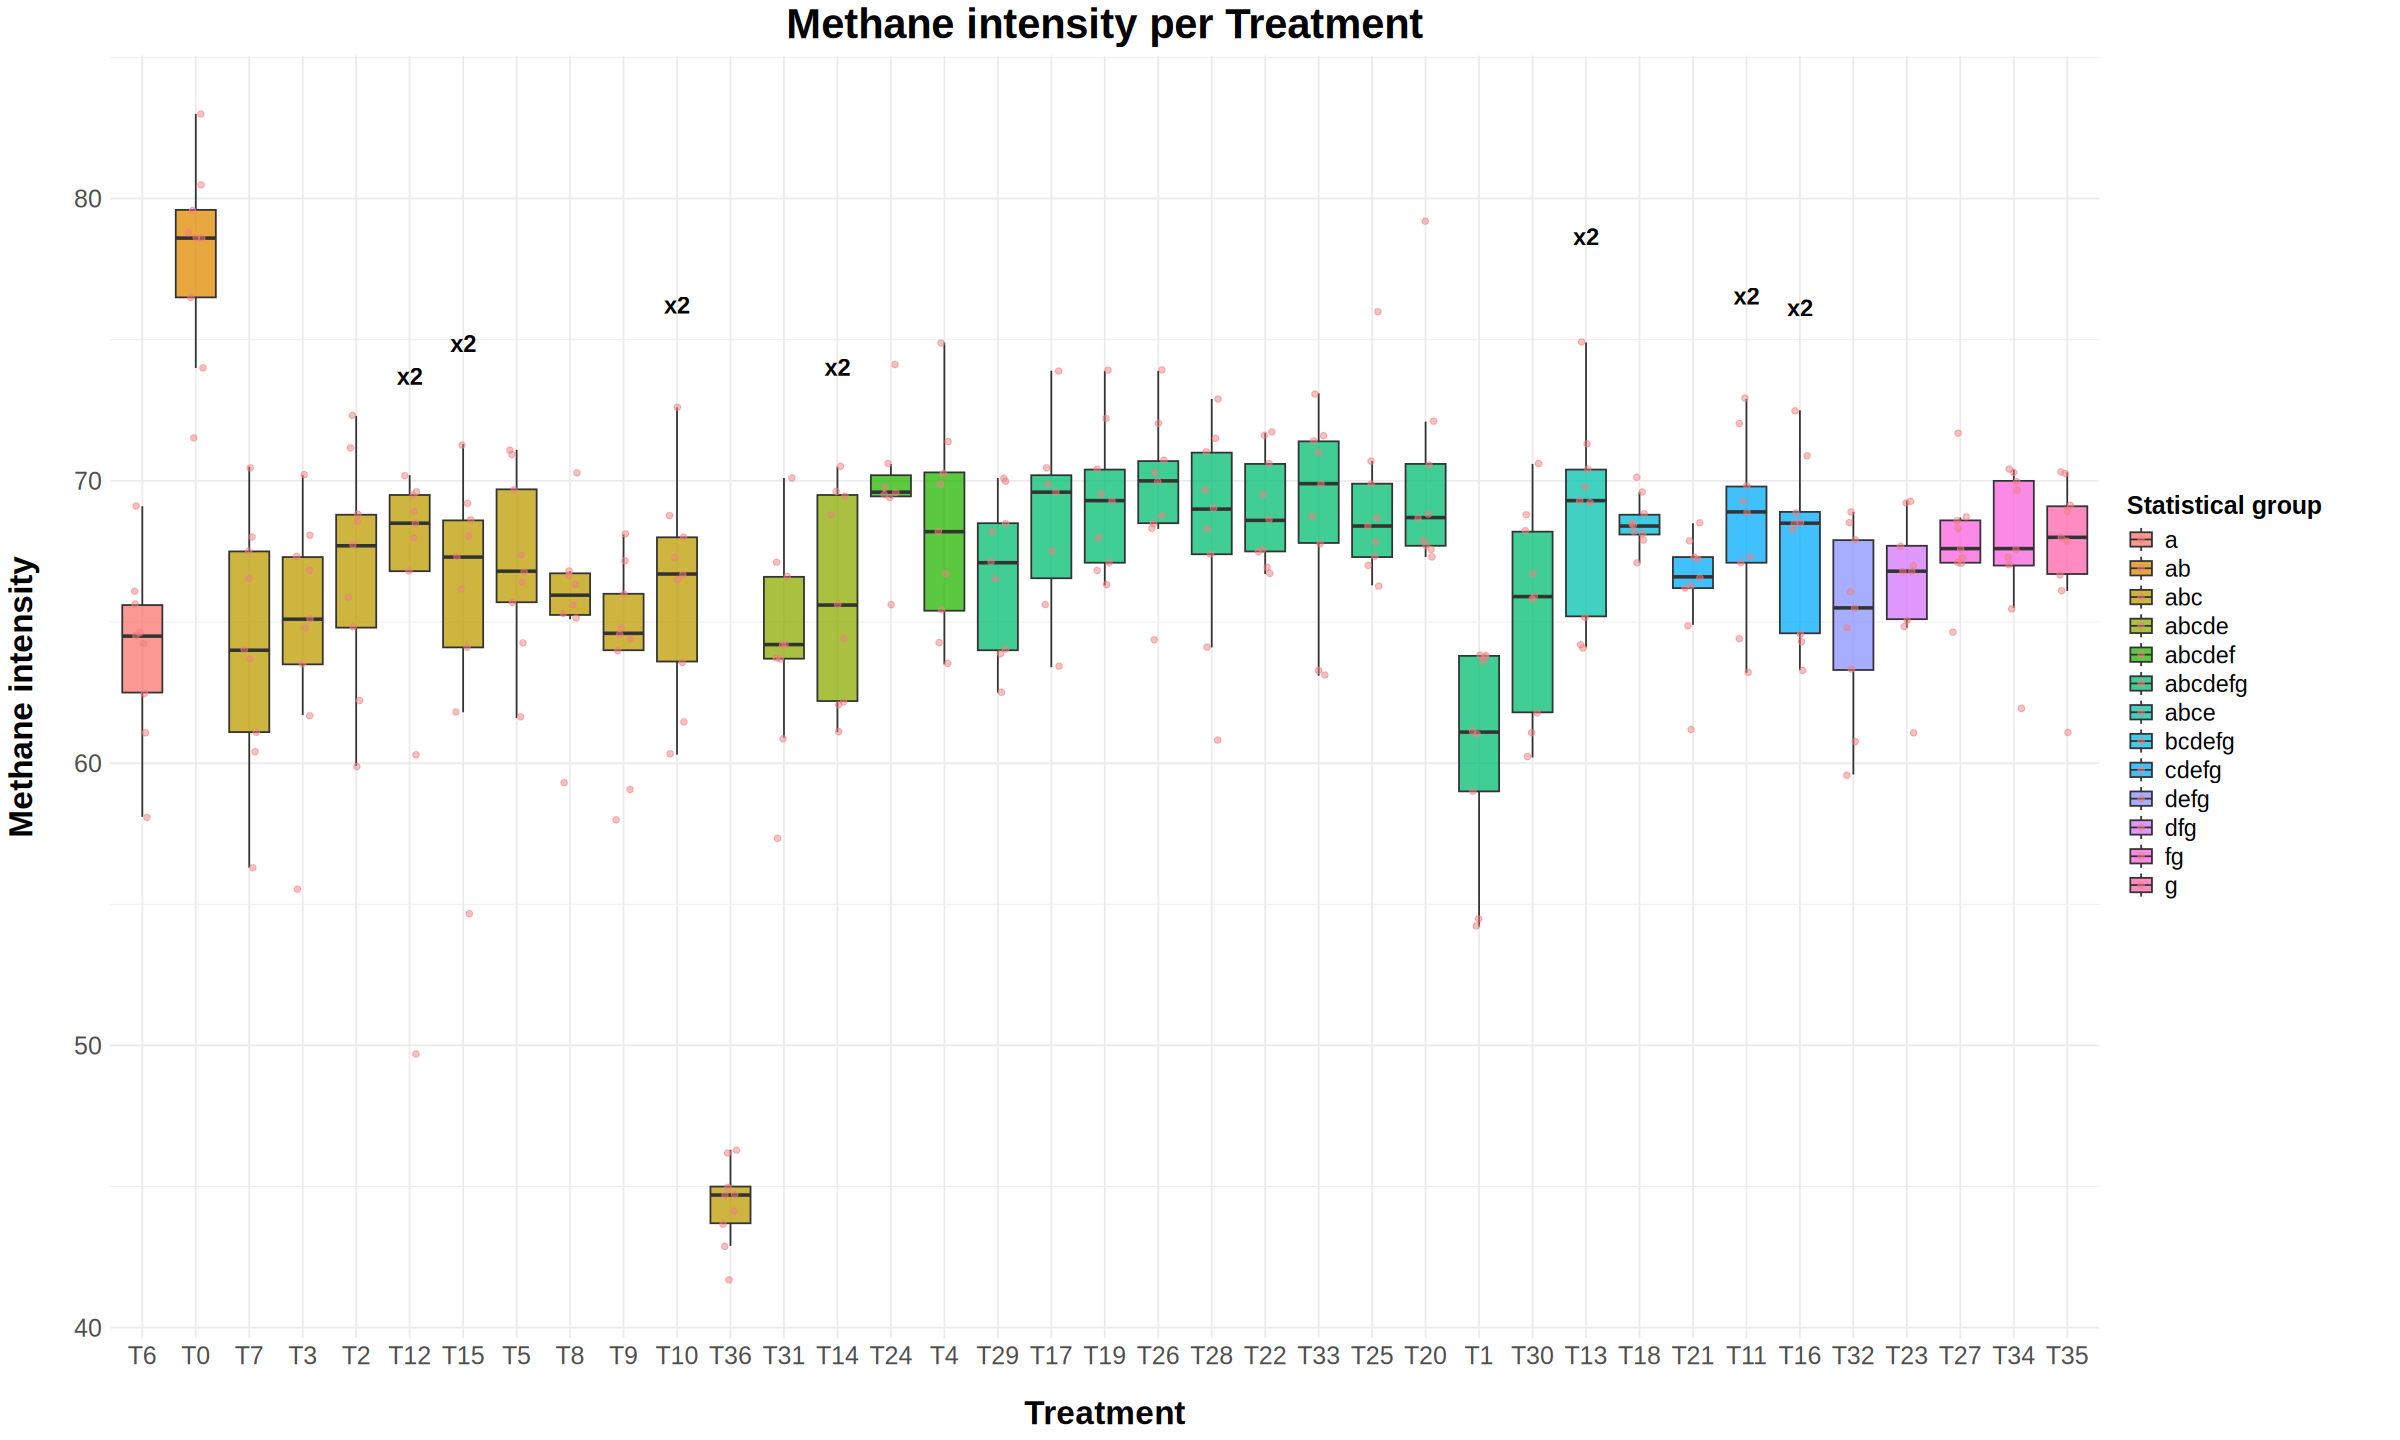

In [182]:
options(repr.plot.width = 20, repr.plot.height = 12)

# ============================================================
# 1. Treatments where "x2" should be displayed
# ============================================================

x2_treatments <- c("T10", "T11", "T12", "T13", "T14", "T15", "T16")

# ============================================================
# 2. Sort treatments by statistical group and then by mean
# ============================================================

letters_df <- letters_df %>%
  arrange(letter, desc(mean))

# ============================================================
# 3. Add the statistical group to the original dataset
# ============================================================

df_plot <- df %>%
  left_join(
    letters_df %>%
      select(Treatment, letter),
    by = "Treatment"
  )

# ============================================================
# 4. Set the treatment order according to letters_df
# ============================================================

df_plot$Treatment <- factor(
  df_plot$Treatment,
  levels = letters_df$Treatment
)

# ============================================================
# 5. Create positions for the "x2" labels
# ============================================================

x2_labels <- df_plot %>%
  group_by(Treatment) %>%
  summarise(
    y_position = max(TDDM_percentage, na.rm = TRUE) * 1.05,
    .groups = "drop"
  ) %>%
  filter(Treatment %in% x2_treatments)

# ============================================================
# 6. Create the plot
# ============================================================

ggplot(
  df_plot,
  aes(
    x = Treatment,
    y = TDDM_percentage,
    fill = letter
  )
) +

  # Boxplots
  geom_boxplot(
    outlier.shape = NA,
    alpha = 0.75
  ) +

  # Individual observations
  geom_jitter(
    width = 0.15,
    alpha = 0.5,
    color = "lightcoral"
  ) +

  # Add "x2" above selected treatments
  geom_text(
    data = x2_labels,
    aes(
      x = Treatment,
      y = y_position,
      label = "x2"
    ),
    inherit.aes = FALSE,
    size = 5,
    fontface = "bold"
  ) +

  # Labels
  labs(
    title = "Methane intensity per Treatment",
    x = "Treatment",
    y = "Methane intensity",
    fill = "Statistical group"
  ) +

  # Plot theme
  theme_minimal() +

  theme(
    plot.title = element_text(
      size = 25,
      face = "bold",
      hjust = 0.5
    ),

    axis.title.x = element_text(
      size = 20,
      face = "bold",
      margin = margin(t = 20)
    ),

    axis.title.y = element_text(
      size = 20,
      face = "bold",
      margin = margin(r = 20)
    ),

    axis.text.x = element_text(
      size = 15
    ),

    axis.text.y = element_text(
      size = 15
    ),

    legend.title = element_text(
      size = 15,
      face = "bold"
    ),

    legend.text = element_text(
      size = 14
    )
  )

In [ ]:
ggsave(
  filename = "methane_treatments.png",
  dpi = 300,
  width = 20,
  height = 12,
  units = "in"
)